In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

### Import MAE and RMSE dfs

In [2]:
MAE_df = pd.read_csv("Fixed_windows_MAE_df.csv")
MAE_df["date"] = pd.to_datetime(MAE_df["date"])
MAE_df.set_index("date", inplace=True)

RMSE_df = pd.read_csv("Fixed_windows_RMSE_df.csv")
RMSE_df["date"] = pd.to_datetime(RMSE_df["date"])
RMSE_df.set_index("date", inplace=True)


### Plot Stuff

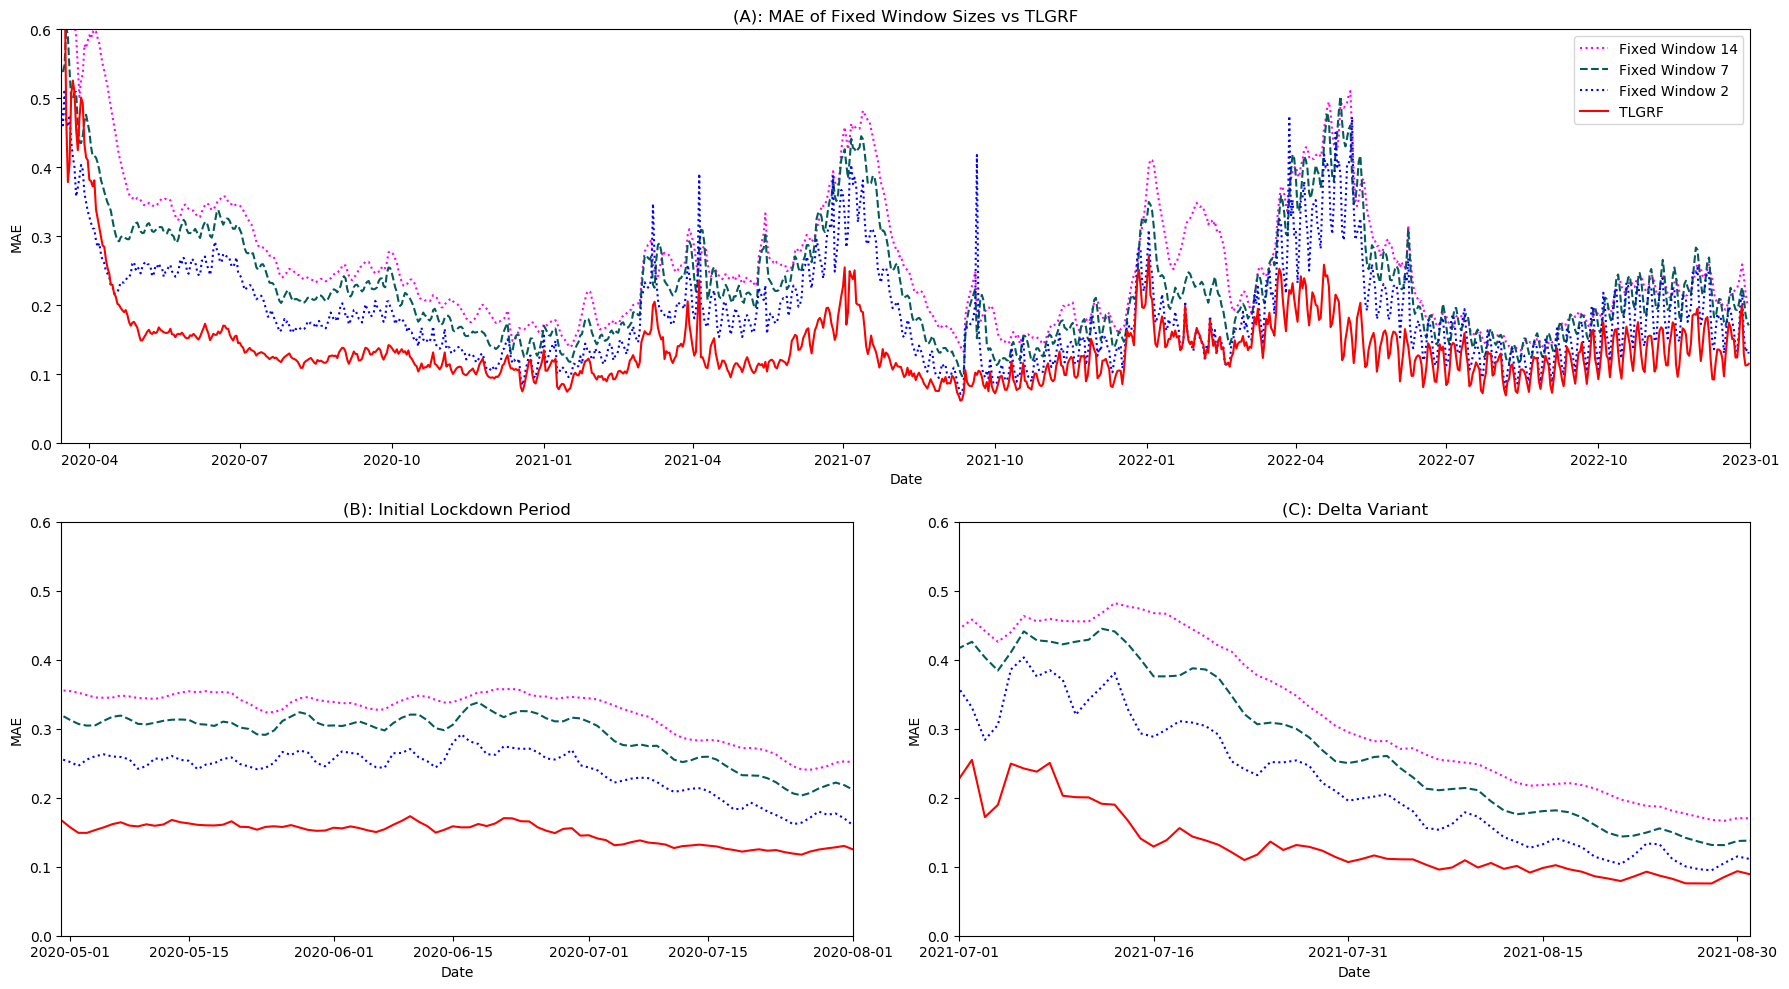

In [3]:
fig = plt.figure(figsize=(18,10))

ax1 = fig.add_subplot(2, 1, 1)
# Create the bottom left subplot
ax2 = fig.add_subplot(2, 2, 3)
# Create the bottom right subplot
ax3 = fig.add_subplot(2, 2, 4)

# Adjust the spacing between subplots
#fig.subplots_adjust(hspace=0.3)

wsizes = [2,7,14]
colors_lm = ["red", "blue", "xkcd:dark turquoise", "magenta"]
colors_lm = list(reversed(colors_lm))

linestyles_lm = ["-","dotted","dashed","dotted"]
linestyles_lm = list(reversed(linestyles_lm))


plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in wsizes]
plot_columns = reversed(plot_columns)

plot_row_names = ["TLGRF"] + ["Fixed Window {}".format(window_size) for window_size in wsizes]
plot_row_names = list(reversed(plot_row_names))

#plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in [2]]
ax1_line_handles = []
for i,plot_column in tqdm(enumerate((plot_columns))):
    ax1_line_handles.append(ax1.plot(MAE_df[plot_column], label=plot_row_names[i], color=colors_lm[i], linestyle=linestyles_lm[i]))
    ax2.plot(MAE_df[plot_column], label=plot_row_names[i], color=colors_lm[i], linestyle=linestyles_lm[i])
    ax3.plot(MAE_df[plot_column], label=plot_row_names[i], color=colors_lm[i], linestyle=linestyles_lm[i])
    
handles = [handle[0] for handle in ax1_line_handles]
labels = [handle[0].get_label() for handle in ax1_line_handles]
locator = mdates.DayLocator(interval=15)
formatter = mdates.DateFormatter('%Y-%m-%d')



ax1.set_xlabel("Date")
ax1.set_ylabel("MAE")
ax1.set_title("(A): MAE of Fixed Window Sizes vs TLGRF")
ax1.set_xlim(pd.to_datetime("2020-03-15"), pd.to_datetime("2023-01-01"))
ax1.set_ylim(0,0.6)
ax1.legend(handles, labels, loc='upper right')

ax2.set_xlabel("Date")
ax2.set_ylabel("MAE")
ax2.set_title("(B): Initial Lockdown Period")
ax2.set_xlim(pd.to_datetime("2020-04-30"), pd.to_datetime("2020-08-01"))
ax2.set_ylim(0,0.6)
#ax2.xaxis.set_major_locator(locator)
#ax2.xaxis.set_major_formatter(formatter)


ax3.set_xlabel("Date")
ax3.set_ylabel("MAE")
ax3.set_title("(C): Delta Variant")
ax3.set_xlim(pd.to_datetime("2021-07-01"), pd.to_datetime("2021-08-31"))
ax3.set_ylim(0,0.6)
ax3.xaxis.set_major_locator(locator)
ax3.xaxis.set_major_formatter(formatter)


#plt.legend()
#fig.legend(handles, labels, loc='upper ')

# Adjust the layout
plt.tight_layout()
plt.savefig("new_lm_grf_mae_together.png")

plt.show()

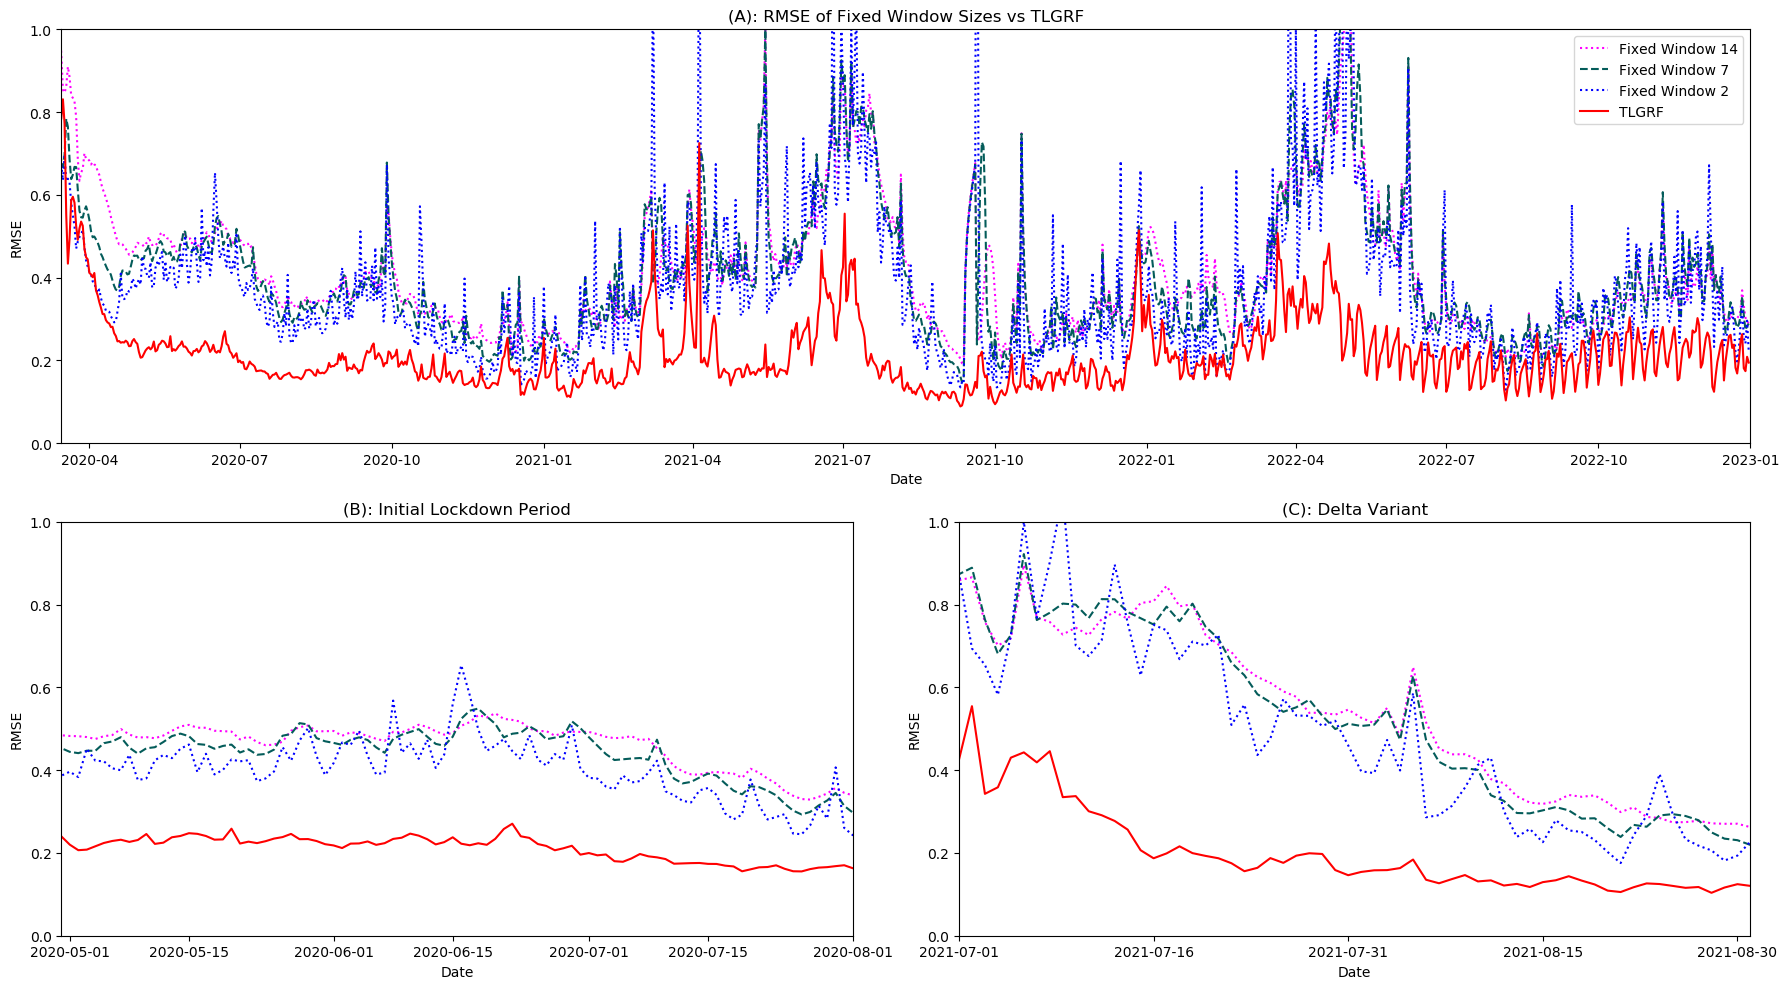

In [4]:
fig = plt.figure(figsize=(18,10))

ax1 = fig.add_subplot(2, 1, 1)
# Create the bottom left subplot
ax2 = fig.add_subplot(2, 2, 3)
# Create the bottom right subplot
ax3 = fig.add_subplot(2, 2, 4)

# Adjust the spacing between subplots
#fig.subplots_adjust(hspace=0.3)

wsizes = [2,7,14]
colors_lm = ["red", "blue", "xkcd:dark turquoise", "magenta"]
colors_lm = list(reversed(colors_lm))

linestyles_lm = ["-","dotted","dashed","dotted"]
linestyles_lm = list(reversed(linestyles_lm))


plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in wsizes]
plot_columns = reversed(plot_columns)

plot_row_names = ["TLGRF"] + ["Fixed Window {}".format(window_size) for window_size in wsizes]
plot_row_names = list(reversed(plot_row_names))

#plot_columns =  ["r_TLGRF"] + ["beta_wsize={}".format(window_size) for window_size in [2]]
ax1_line_handles = []
for i,plot_column in tqdm(enumerate((plot_columns))):
    ax1_line_handles.append(ax1.plot(RMSE_df[plot_column], label=plot_row_names[i], color=colors_lm[i], linestyle=linestyles_lm[i]))
    ax2.plot(RMSE_df[plot_column], label=plot_row_names[i], color=colors_lm[i], linestyle=linestyles_lm[i])
    ax3.plot(RMSE_df[plot_column], label=plot_row_names[i], color=colors_lm[i], linestyle=linestyles_lm[i])
    
handles = [handle[0] for handle in ax1_line_handles]
labels = [handle[0].get_label() for handle in ax1_line_handles]
locator = mdates.DayLocator(interval=15)
formatter = mdates.DateFormatter('%Y-%m-%d')



ax1.set_xlabel("Date")
ax1.set_ylabel("RMSE")
ax1.set_title("(A): RMSE of Fixed Window Sizes vs TLGRF")
ax1.set_xlim(pd.to_datetime("2020-03-15"), pd.to_datetime("2023-01-01"))
ax1.set_ylim(0,1)
ax1.legend(handles, labels, loc='upper right')

ax2.set_xlabel("Date")
ax2.set_ylabel("RMSE")
ax2.set_title("(B): Initial Lockdown Period")
ax2.set_xlim(pd.to_datetime("2020-04-30"), pd.to_datetime("2020-08-01"))
ax2.set_ylim(0,1)
#ax2.xaxis.set_major_locator(locator)
#ax2.xaxis.set_major_formatter(formatter)


ax3.set_xlabel("Date")
ax3.set_ylabel("RMSE")
ax3.set_title("(C): Delta Variant")
ax3.set_xlim(pd.to_datetime("2021-07-01"), pd.to_datetime("2021-08-31"))
ax3.set_ylim(0,1)
ax3.xaxis.set_major_locator(locator)
ax3.xaxis.set_major_formatter(formatter)


#plt.legend()
#fig.legend(handles, labels, loc='upper ')

# Adjust the layout
plt.tight_layout()
plt.savefig("new_lm_grf_rmse_together.png")

plt.show()